In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
from rdkit import Chem
from rdkit.Chem import Draw
from src.datasets import QM9Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
qm9 = QM9Dataset()
qm9.load(force_process=False)
qm9.df.head(5)

2026-03-06 11:29:20.375 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...


mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_0""","""[H]C([H])([H])[H]""","""[H]C([H])([H])[H]""","""[H][C][Branch1][C][H][Branch1]…",5,"""Acyclic""",16,0,0,1,0,0,0,1.0,0,0,1,0,0,1,2,9,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985
"""qm9_1""","""[H]N([H])[H]""","""[H]N([H])[H]""","""[H][N][Branch1][C][H][H]""",4,"""Acyclic""",17,0,35,1,0,0,0,0.0,1,1,1,0,0,0,2,6,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967
"""qm9_2""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0,0,0,0,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465
"""qm9_3""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""",4,"""Acyclic""",26,0,0,2,0,0,0,0.0,0,0,0,2,0,0,3,4,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035
"""qm9_4""","""[H]C#N""","""[H]C#N""","""[H][C][#N]""",3,"""Acyclic""",27,0,23,2,0,0,0,0.0,0,1,0,1,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884


In [4]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_115""","""[H]C([H])([H])C#CC([H])([H])C(…","""[H]C([H])([H])C#CC([H])([H])C(…","""[H][C][Branch1][C][H][Branch1]…",13,"""Acyclic""",68,1,0,5,0,0,1,0.6,0,0,3,2,0,3,6,25,0,0,0,0,0,0,0,0,0,0,0,0.078,53.93,-6.533453,1.717039,8.253213,652.481201,3.068383,-5311.57373,-5311.387207,-5311.361328,-5312.428711,22.115,-53.353561,-53.667633,-53.976101,-49.909634,20.506491,2.07478,1.95249
"""qm9_515""","""[H]C#CC([H])([H])C([H])([H])C(…","""[H]C#CC([H])([H])C([H])([H])C(…","""[H][C][#C][C][Branch1][C][H][B…",16,"""Acyclic""",82,1,0,6,0,0,3,0.666667,0,0,4,2,0,4,7,32,0,0,0,0,0,0,0,0,0,0,0,0.835,62.82,-7.017817,1.597308,8.615125,950.827209,3.842928,-6380.378906,-6380.170898,-6380.145508,-6381.235352,26.865,-65.06926,-65.477814,-65.863396,-60.651299,14.85379,1.31677,1.24669
"""qm9_1370""","""[H]C(=O)N(C([H])([H])[H])C([H]…","""[H]C(=O)N(C([H])([H])[H])C([H]…","""[H][C][=Branch1][C][=O][N][Bra…",13,"""Acyclic""",98,0,44,7,0,0,2,0.5,0,2,4,1,1,2,5,25,0,0,0,0,1,0,0,0,0,0,3,3.2465,56.220001,-7.377007,-0.035375,7.344353,848.353699,2.755343,-9269.991211,-9269.786133,-9269.759766,-9270.869141,25.108999,-55.643944,-55.939812,-56.248199,-51.973454,5.91579,1.51412,1.39501
"""qm9_50""","""[H]C1=NC([H])=C([H])N1[H]""","""[H]c1nc([H])n([H])c1[H]""","""[H][C][N][=C][Branch1][C][H][N…",9,"""Aromatic""",68,0,28,5,1,1,0,0.0,1,1,4,0,3,0,4,15,0,0,0,0,0,0,0,0,0,0,2,3.6193,39.130001,-6.130725,0.903418,7.034143,283.681702,1.935954,-6154.149902,-6154.047852,-6154.021973,-6154.864746,13.371,-39.503101,-39.74781,-39.953423,-37.052414,9.77329,9.41192,4.7946
"""qm9_1790""","""[H]C1=C(N([H])[H])C([H])([H])N…","""[H]C1=C(N([H])[H])C([H])([H])N…","""[H][C][=C][Branch1][=Branch1][…",13,"""Aliphatic Ring""",98,-1,55,7,1,0,1,0.25,2,2,6,0,3,1,5,25,0,0,0,1,1,0,0,0,0,0,3,5.8308,58.169998,-6.000111,-0.010885,5.989226,720.031311,2.825848,-9270.571289,-9270.397461,-9270.37207,-9271.384766,24.108,-56.224033,-56.551853,-56.860268,-52.488922,6.59864,2.09614,1.61117
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2041""","""[H]O[C@]1([H])C([H])([H])N=C([…","""[H]O[C@]1([H])C([H])([H])N=C([…","""[H][O][C@][Branch1][C][H][C][B…",14,"""Aliphatic Ring""",101,0,41,7,1,0,1,0.75,1,3,4,0,1,3,6,26,0,1,0,0,0,0,0,0,1,0,3,2.5699,53.869999,-6.78652,0.647631,7.436872,681.248779,3.13467,-9842.833984,-9842.661133,-9842.634766,-9843.65332,23.334999,-57.564362,-57.931305,-58.265434,-53.548393,5.03136,2.50139,1.76859
"""qm9_1270""","""[H]O[C@@]1(C([H])([H])[H])C(=O…","""[H]O[C@@]1(C([H])([H])[H])C(=O…","""[H][O][C@@][Branch1][=Branch2]…",15,"""Aliphatic Ring""",100,0,37,7,1,0,2,0.8,1,2,5,0,1,4,5,31,0,1,0,0,0,0,0,1,0,0,2,2.0822,57.220001,-6.726655,-0.778246,5.948409,682.464417,3.341313,-9405.979492,-9405.772461,-9405.746094,-9406.842773,27.353001,-62.536777,-62.907696,-63.26754,-58.287693,3.39434,2.71916,2.16812
"""qm9_563""","""[H]C#CC([H])([H])[NH+]1C([H])(…","""[H]C#CC([H])([H])[N+]1([H])C([…","""[H][C][#C][C][Branch1][C][H][B…",13,"""Aliphatic Ring""",82,-1,4,6,1,0,1,0.6,1,0,4,2,0,3,6,28,0,0,0,0,0,0,0,0,0,0,1,0.8803,54.939999,-6.503521,1.036754,7.540275,568.503479,2.917986,-6783.283203,-6783.11377,-6783.087891,-6784.089355,22.525,-53.373562,-53.704918,-54.013355,-49.761684,7.39757,2.68675,2.36455


In [5]:
qm9.df.filter(pl.col("canonical_smiles").is_duplicated())

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

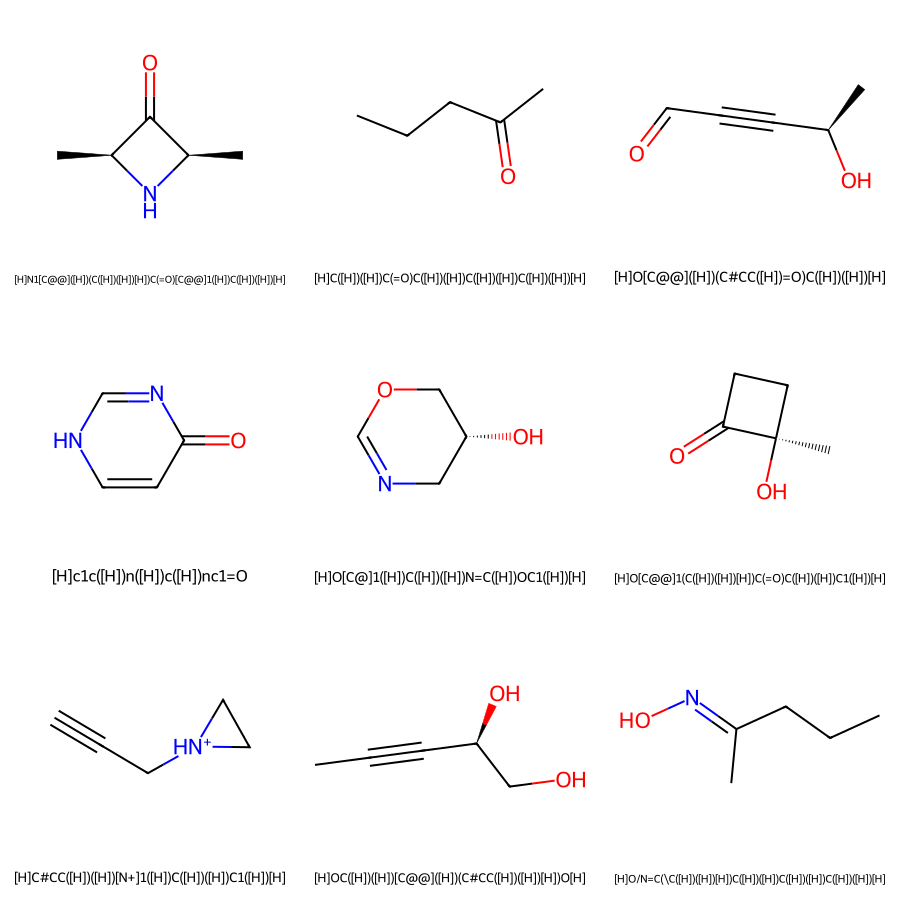

In [6]:
sample_smiles = qm9.df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

# Figures for report

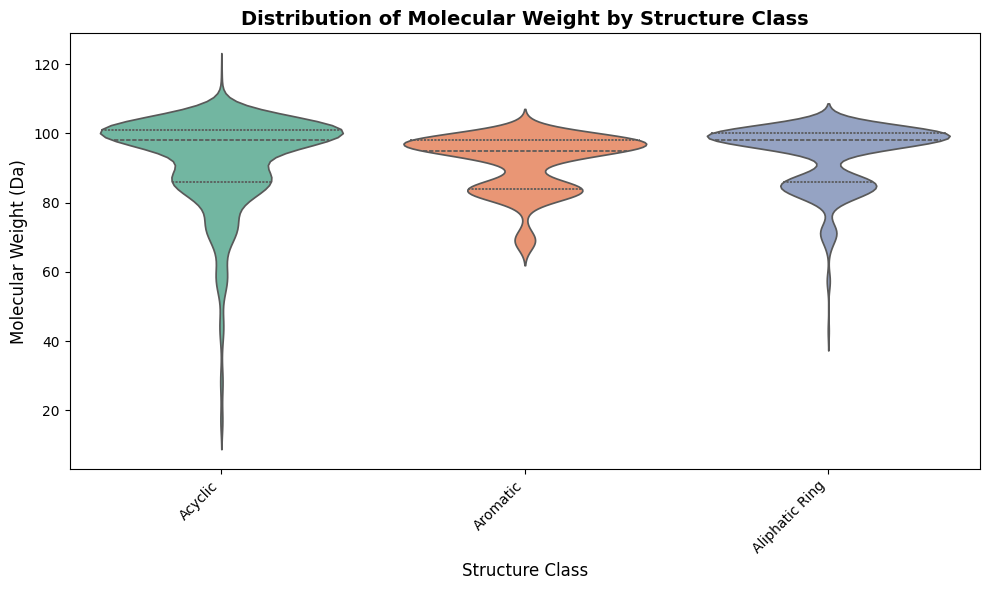

In [7]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=qm9.df, 
    x='structure_class', 
    y='mol_weight', 
    palette='Set2', 
    hue='structure_class',
    inner='quartile'
)
plt.title('Distribution of Molecular Weight by Structure Class', fontsize=14, fontweight='bold')
plt.xlabel('Structure Class', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

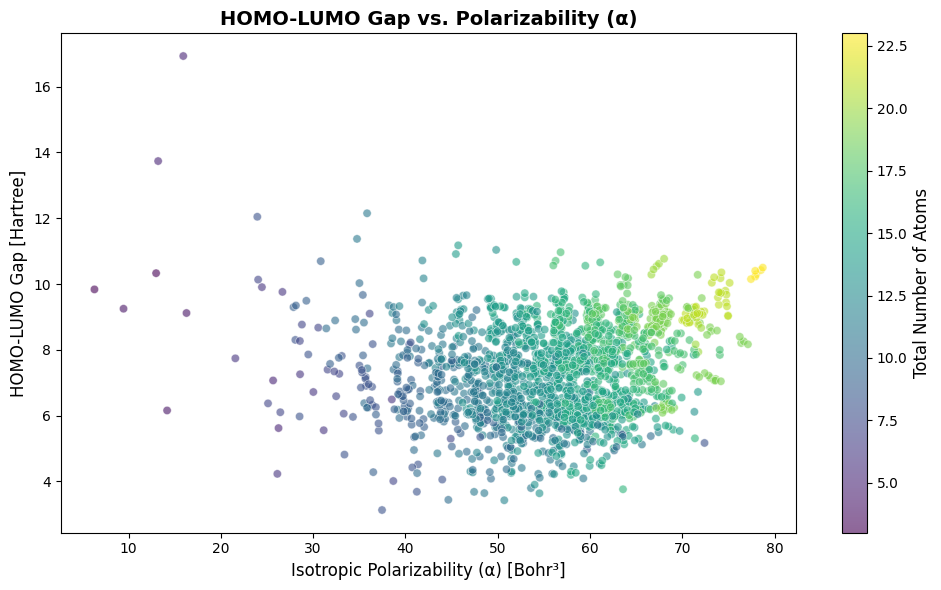

In [8]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    qm9.df['alpha'], 
    qm9.df['gap'], 
    c=qm9.df['num_atoms'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Number of Atoms', fontsize=12)

plt.title('HOMO-LUMO Gap vs. Polarizability (α)', fontsize=14, fontweight='bold')
plt.xlabel('Isotropic Polarizability (α) [Bohr³]', fontsize=12)
plt.ylabel('HOMO-LUMO Gap [Hartree]', fontsize=12)
plt.tight_layout()
plt.show()

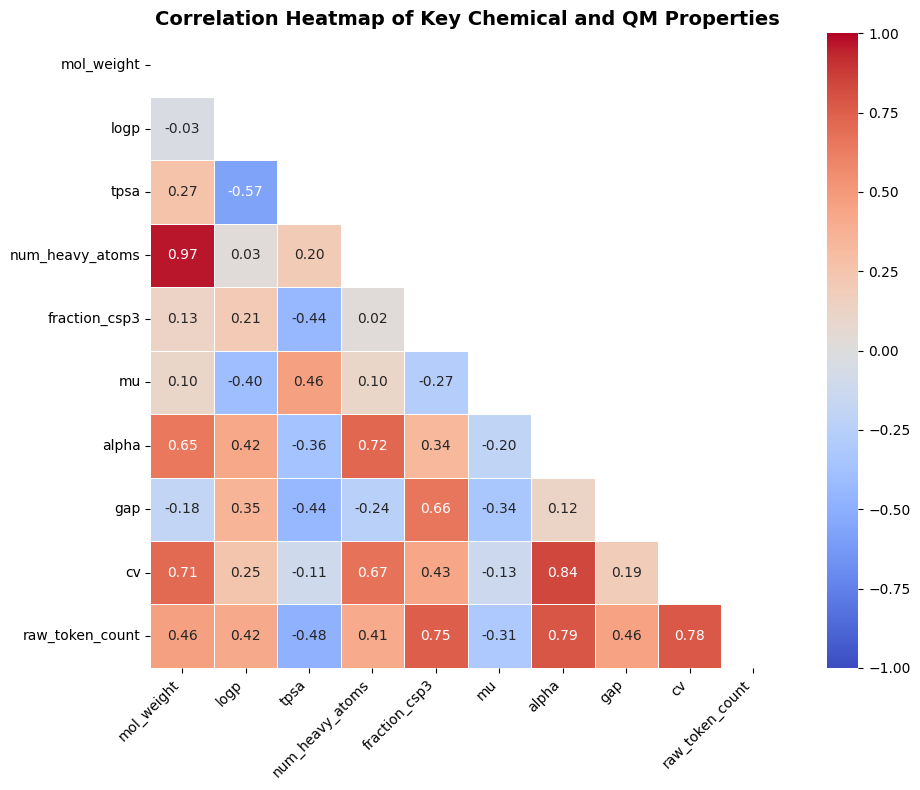

In [9]:
plt.figure(figsize=(10, 8))

# Select a mix of 2D cheminformatics features and 3D quantum features
features_of_interest = [
    'mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 
    'fraction_csp3', 'mu', 'alpha', 'gap', 'cv', 'raw_token_count'
]

# Calculate Spearman correlation (better for potentially non-linear chemical features)
corr = qm9.df[features_of_interest].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    xticklabels=features_of_interest,   # ← use names instead of 0,1,2…
    yticklabels=features_of_interest
)

plt.xticks(rotation=45, ha='right')      # if you want them tilted
plt.title('Correlation Heatmap of Key Chemical and QM Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
qm9.df['structure_class']

structure_class
str
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
"""Aromatic"""
"""Aliphatic Ring"""
…
"""Aliphatic Ring"""
"""Aliphatic Ring"""
"""Aliphatic Ring"""


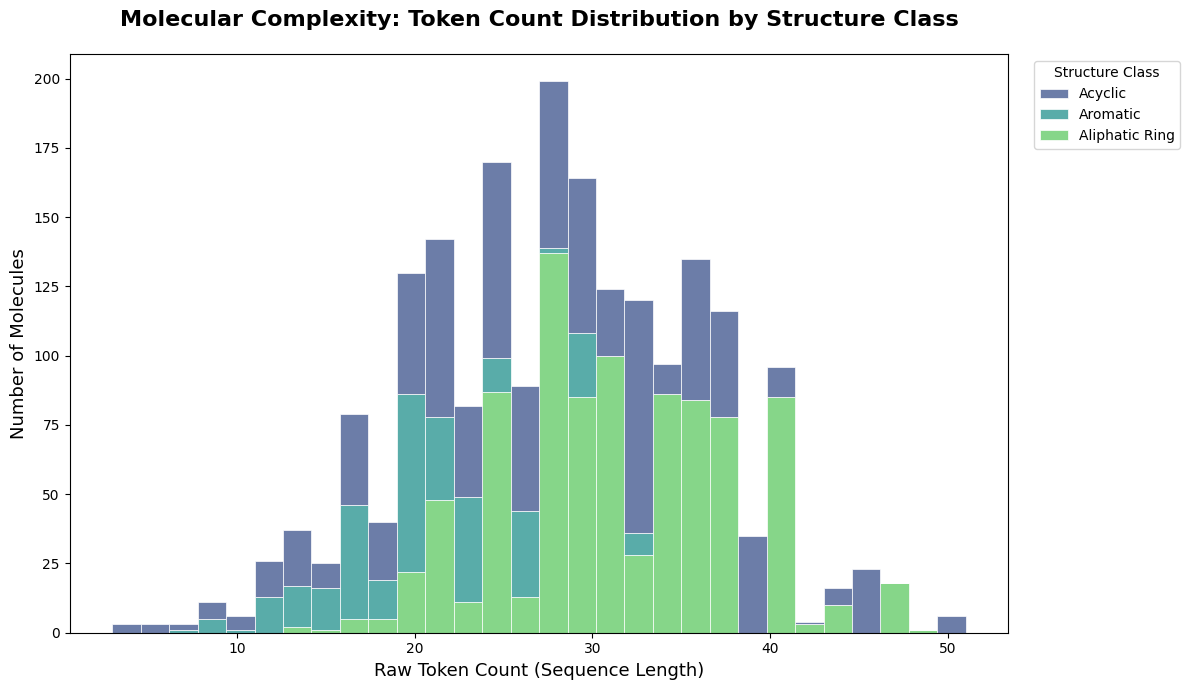

In [11]:
plt.figure(figsize=(12, 7))

# 1. Create the plot (Seaborn creates the legend automatically here)
ax = sns.histplot(
    data=qm9.df,
    x='raw_token_count',
    hue='structure_class',
    multiple='stack',
    palette='viridis',
    edgecolor='white',
    linewidth=0.5,
    bins=30
)

# 2. Access the auto-generated legend and move it
# This avoids the "No artists with labels found" warning
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Structure Class')

plt.title('Molecular Complexity: Token Count Distribution by Structure Class', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Raw Token Count (Sequence Length)', fontsize=13)
plt.ylabel('Number of Molecules', fontsize=13)

plt.tight_layout()
plt.savefig('report/qm9/figures/initial_analysis/plot_token_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

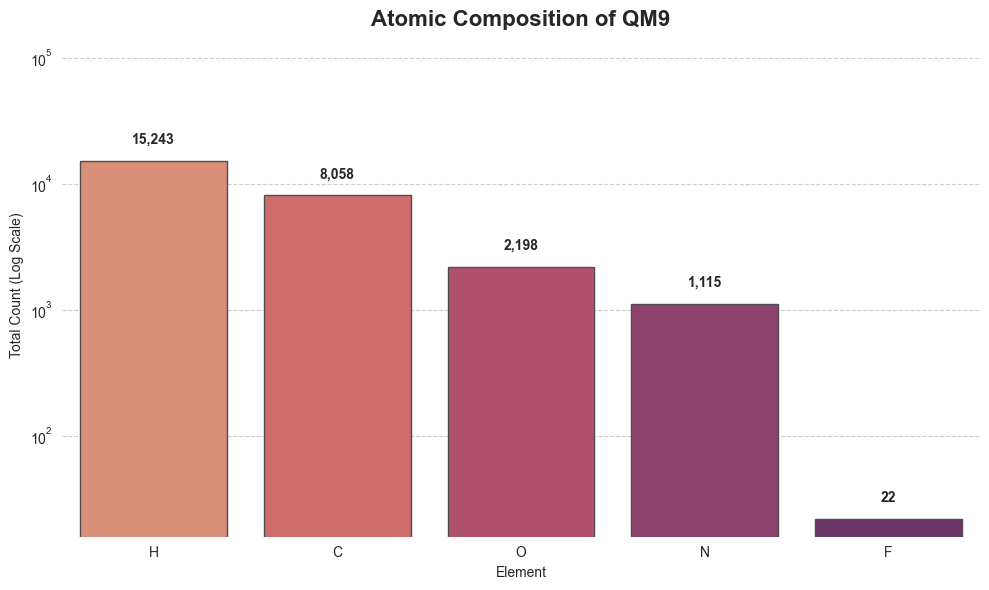

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# 1. Processing - Using map(str) to avoid the AttributeError
all_smiles = "".join(map(str, qm9.df["canonical_smiles"]))

# Regex: Find Capital letters followed by optional lowercase (Elements)
# We filter out common SMILES syntax that isn't an element
tokens = re.findall(r'[A-Z][a-z]?', all_smiles)
valid_elements = {'H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'P', 'Br', 'I'}
atom_counts = Counter([t for t in tokens if t in valid_elements])

comp_df = pd.DataFrame(atom_counts.items(), columns=['Element', 'Count'])
comp_df = comp_df.sort_values('Count', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--'})

ax = sns.barplot(
    data=comp_df, 
    x='Element', 
    y='Count', 
    palette='flare',
    hue='Element',
    edgecolor='0.3'
)

ax.set_yscale("log")
plt.ylim(top=comp_df['Count'].max() * 10) # Added more headroom for labels

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Atomic Composition of QM9', fontsize=16, fontweight='bold')
plt.ylabel('Total Count (Log Scale)')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('report/qm9/figures/initial_analysis/atomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Average weight of molecule

In [13]:
mol_weights = qm9.df['mol_weight']
print(np.average(mol_weights))

92.4385


# Similar Molecules for Grassmann stress test

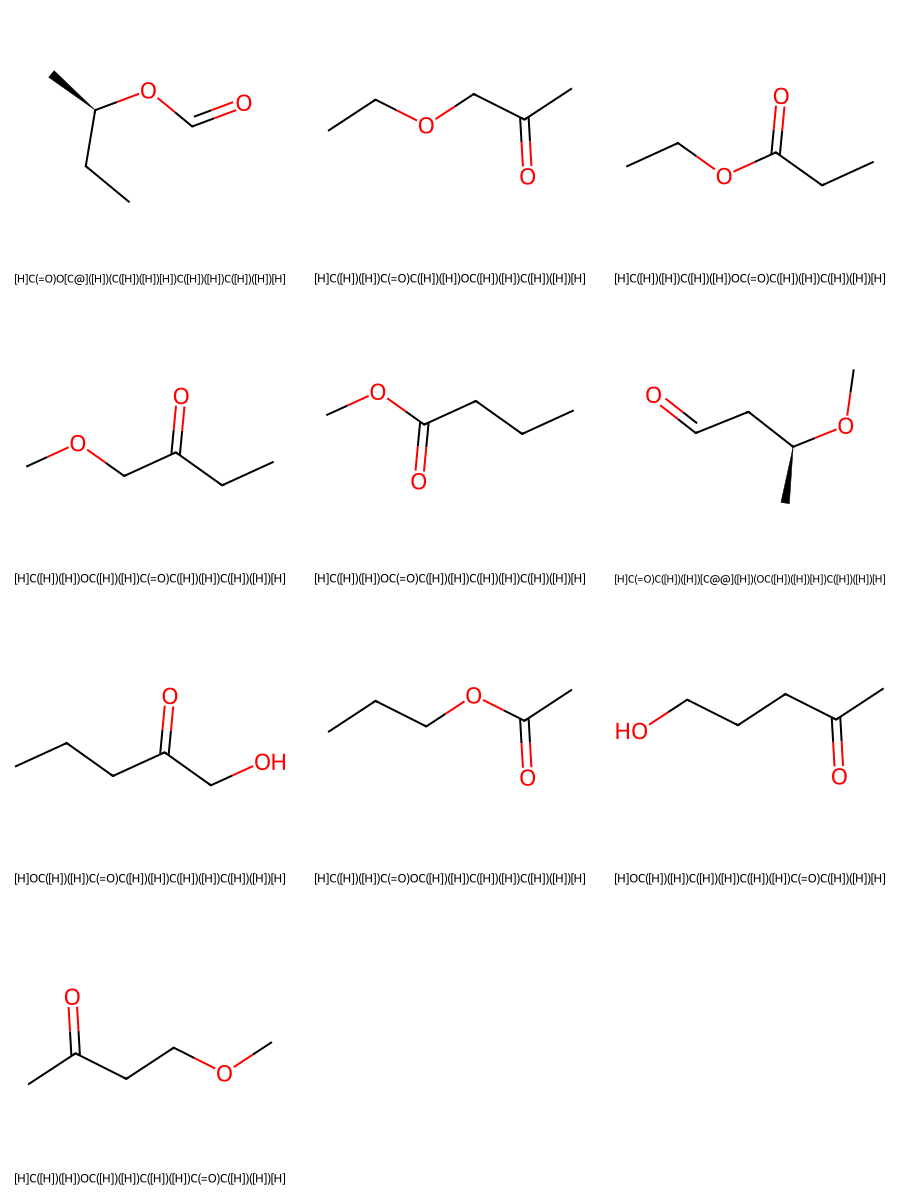

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd

df = qm9.df.to_pandas()
# Assuming your dataframe is named 'df'
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

# FIX: Use boolean indexing instead of .filter()
sample_smiles = df[df["mol_id"].isin(mol_ids)]["canonical_smiles"].tolist()

# Generate molecules
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

# Create the grid image
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img